In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [114]:
data=pd.read_csv('/content/Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [115]:
def analyzer(max_depth):
  data=pd.read_csv('/content/Social_Network_Ads.csv')
  X=data.iloc[:,2:4].values
  y=data.iloc[:,-1].values

  clf=DecisionTreeClassifier(max_depth=max_depth)
  clf.fit(X,y)

  a=np.arange(start=X[:,0].min()-1,stop=X[:,0].max()+1,step=0.1)
  b=np.arange(start=X[:,1].min()-1,stop=X[:,1].max()+1,step=100)

  XX,YY=np.meshgrid(a,b)

  input_array=np.array([XX.ravel(),YY.ravel()]).T
  labels=clf.predict(input_array)
  plt.contour(XX,YY,labels.reshape(XX.shape),alpha=0.5)
  plt.scatter(X[:,0],X[:,1],c=y)

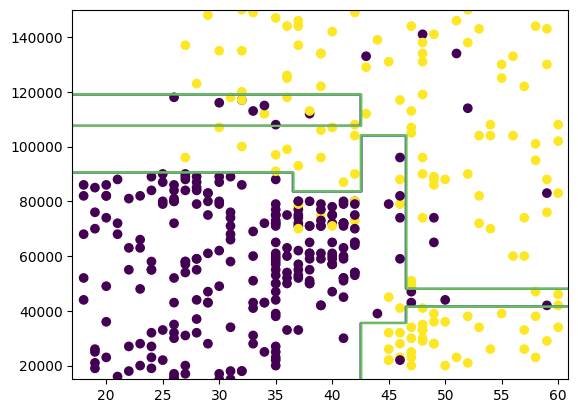

In [116]:
analyzer(max_depth=4)

In [117]:
X=data.iloc[:,2:4].values
y=data.iloc[:,-1].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

clf=DecisionTreeClassifier(criterion='entropy',splitter='best',max_depth=2,min_samples_split=200,min_samples_leaf=10,max_features=2,max_leaf_nodes=3,min_impurity_decrease=0.2)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.9375